In [1]:
# !/usr/bin/env python3
'''
Test out usage of fast1 library API for data extraction.
  - Check with Monza 2019 dataset.
  - Default driver is Leclerc.
  - Want to get:
  		- telemetry data for first lap
		- lap time
		- sector times
		- speed trap data
		- weather data
		- tire data
		  - Output as dictionary.

'''

import fastf1

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import colormaps
from matplotlib.collections import LineCollection


In [ ]:
# Move to the root of your project
%cd SpeedDemon/

# Enable autoreload for module changes
%load_ext autoreload
%autoreload 2

/Users/bchu/OfflineDocuments/Github/Website/projects/ML/SpeedDemon
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [13]:
from notebooks.eda.track_visualization_transformations import *

In [8]:
# Setup cache
cache_dir = "data/.cache/fastf1"
fastf1.Cache.enable_cache(cache_dir)

## Familiarizing

In [ ]:
schedule = fastf1.get_event_schedule(2019)
schedule.head()

In [ ]:
schedule[["RoundNumber", "Country", "EventDate"]]

In [ ]:
# Choose which track and year to visualize
year = 2023
circuit = 'Silverstone'

In [ ]:
# Get session data and print the year's tracks as series/dataframes
session = fastf1.get_session(year, circuit, 'R')

print(type(session), type(session.event))
print(session.event['EventName'])
session.__dict__.keys()

Each session load ~ 50MB

In [ ]:
session.load()  # Load the session data

## See Track with Corner Markers

In [ ]:
# Track visualizations with corner numbers
# driver = 'LEC'
# lap_number = 1
# lap = session.laps.pick_drivers(driver).pick_laps(lap_number)
lap = session.laps.pick_fastest()
tel = lap.get_telemetry()
pos = lap.get_pos_data()
location = session.event["Location"]

circuit_info = session.get_circuit_info()


In [ ]:

# Create figure and axis

(fig, ax), (track_fig, track_ax) = plot_track_with_labeled_corners(None, None, session)

# Can display fig with: plt.show(fig) or fig
# Can display track_fig with: plt.show(track_fig) or track_fig

In [ ]:
print(session.__dict__.keys())
print(schedule.keys())

## Test Speed Contour Visualization

In [9]:
# get speed over the lap data
year = 2023
wknd = 8
ses = 'R'
driver = 'LEC'
colormap = mpl.cm.plasma

In [10]:
session = fastf1.get_session(year, wknd, ses)
weekend = session.event
session.load()

lap = session.laps.pick_drivers(driver).pick_fastest()


core           INFO 	Loading data for Canadian Grand Prix - Race [v3.7.0]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	Fixed incorrect tyre stint information for driver '22'
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '14', '44', '16', '55', '11', '23', '31', '18', '77', '81', '10', '4', '22', '27', '24', '20', '

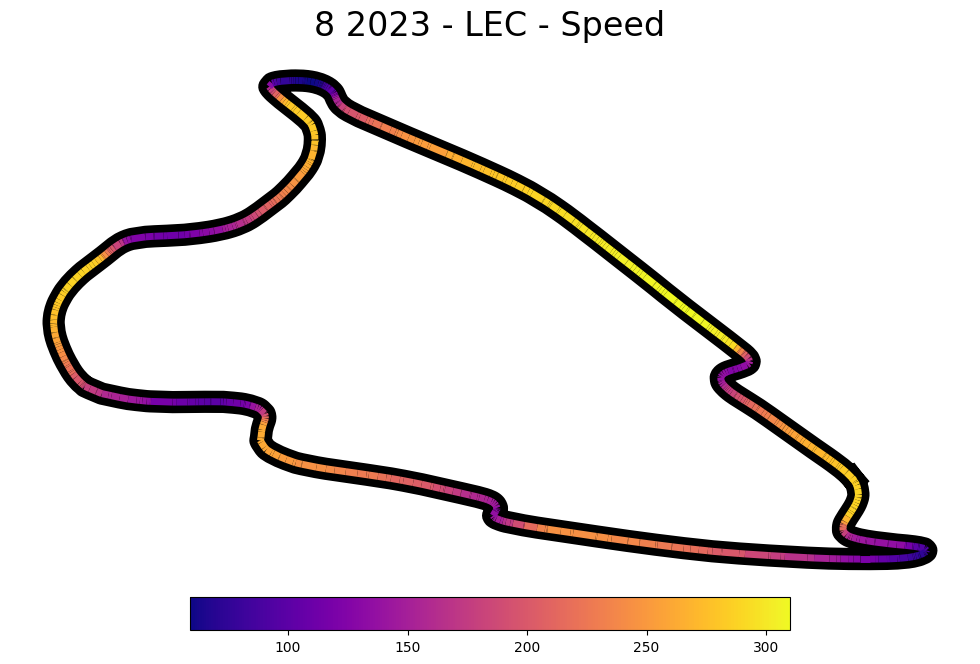

In [ ]:
fig_speed, ax_speed = plot_track_speed_contour(colormap, weekend, session, driver, lap)

## Plot Speed Traces with Corner

In [14]:
# load a session and its telemetry data
session = fastf1.get_session(2021, 'Spanish Grand Prix', 'Q')
session.load()

fastest_lap = session.laps.pick_fastest()
car_data = fastest_lap.get_car_data().add_distance()

# get info about corners as well
circuit_info = session.get_circuit_info()

core           INFO 	Loading data for Spanish Grand Prix - Qualifying [v3.7.0]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for _extended_timing_data. Loading data...
_api           INFO 	Fetching timing data...
_api           INFO 	Parsing timing data...
req            INFO 

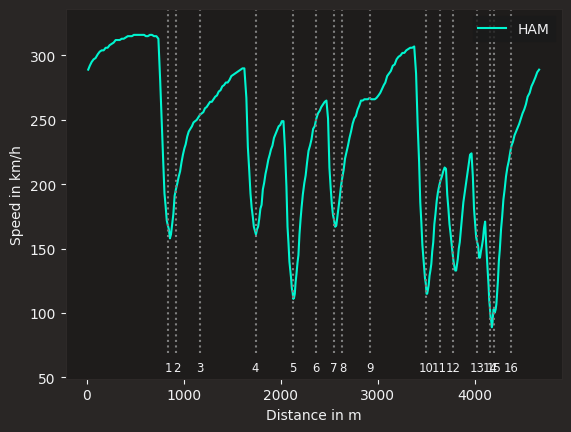

In [ ]:
fig_fastest, ax_fastest = plot_speed_traces_with_corner(session)